Outliers (IQR) - serie1: [30]
Outliers (IQR) - serie2: [29, 30]
Outliers (MAD) - serie1: [30]
Outliers (MAD) - serie2: [29, 30]

=== Welch t-test (dados brutos) ===
{'n1': 31, 'n2': 31, 'mean1': np.float64(20.562012016060503), 'mean2': np.float64(21.482190445835382), 't': np.float64(-0.4542953507152023), 'p': np.float64(0.6512580543542846), 'ci95': (np.float64(-4.971925575465982), np.float64(3.1315687159162247)), 'df_welch': np.float64(59.90666985161062)}

=== Welch t-test (sem outliers IQR) ===
{'n1': 30, 'n2': 29, 'mean1': np.float64(19.247412416595854), 'mean2': np.float64(21.205100131755064), 't': np.float64(-1.811616503060998), 'p': np.float64(0.07572189572068395), 'ci95': (np.float64(-4.125235044955868), np.float64(0.20985961463744873)), 'df_welch': np.float64(52.919050732902775)}

=== Welch t-test (winsorizado IQR) ===
{'n1': 31, 'n2': 31, 'mean1': np.float64(19.52494232297224), 'mean2': np.float64(21.207693094770217), 't': np.float64(-1.3910098017427572), 'p': np.float64(0.1699

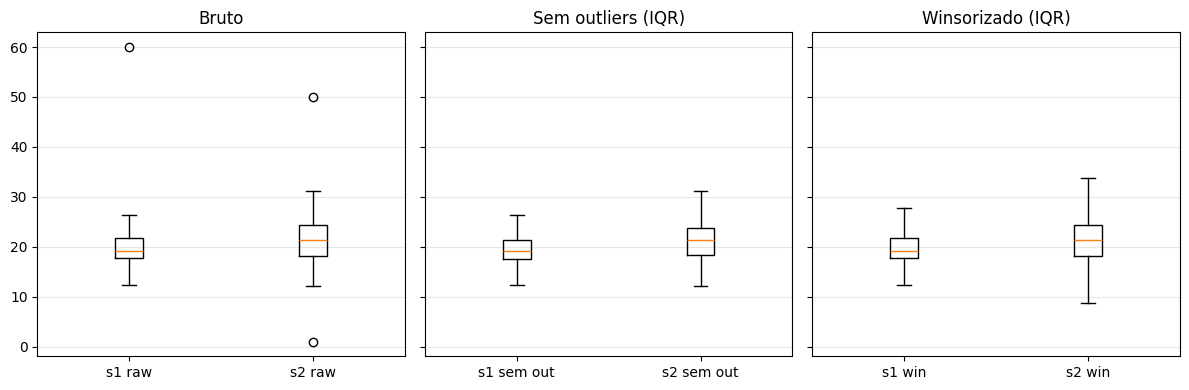

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# --- 1) Método IQR (Tukey) ---
def detect_outliers_iqr(x, k=1.5):
    x = pd.Series(x).dropna()
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    mask = (x < lower) | (x > upper)
    return mask.index[mask], (lower, upper)

# --- 2) Z-score clássico ---
def detect_outliers_zscore(x, z_thresh=3.0):
    x = pd.Series(x).dropna()
    z = (x - x.mean()) / x.std(ddof=1)
    mask = z.abs() > z_thresh
    return mask.index[mask], z

# --- 3) Z-score robusto (MAD) ---
def detect_outliers_robust(x, z_thresh=3.5):
    """
    Usa mediana e MAD (Median Absolute Deviation).
    z_robusto = 0.6745 * (x - mediana) / MAD
    """
    x = pd.Series(x).dropna()
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0:
        # Sem dispersão robusta mensurável; retorna vazio
        return pd.Index([]), pd.Series(np.zeros_like(x), index=x.index, dtype=float)
    z_rob = 0.6745 * (x - med) / mad
    mask = z_rob.abs() > z_thresh
    return mask.index[mask], z_rob

# --- Winsorização (aparar extremos para o limite) ---
def winsorize_iqr(x, k=1.5):
    x = pd.Series(x).copy()
    idx, (lower, upper) = detect_outliers_iqr(x, k=k)
    x_clip = x.clip(lower=lower, upper=upper)
    return x_clip

# Exemplo de dados sintéticos (substitua pelo seu df real)
np.random.seed(42)
df = pd.DataFrame({
    'serie1': np.r_[np.random.normal(20, 4, 30), [60]],  # injeta um outlier
    'serie2': np.r_[np.random.normal(22, 5, 29), [1, 50]]  # injeta dois outliers
})

# --- 1) Extrair valores (independentes ⇒ NaNs retirados separadamente) ---
s1_raw = df['serie1'].dropna()
s2_raw = df['serie2'].dropna()

# --- 2) Detectar outliers em cada série (escolha o método) ---
# IQR (padrão prático)
out_idx_1_iqr, (low1, up1) = detect_outliers_iqr(s1_raw, k=1.5)
out_idx_2_iqr, (low2, up2) = detect_outliers_iqr(s2_raw, k=1.5)

# MAD (robusto)
out_idx_1_mad, zrob1 = detect_outliers_robust(s1_raw, z_thresh=3.5)
out_idx_2_mad, zrob2 = detect_outliers_robust(s2_raw, z_thresh=3.5)

print("Outliers (IQR) - serie1:", list(out_idx_1_iqr))
print("Outliers (IQR) - serie2:", list(out_idx_2_iqr))
print("Outliers (MAD) - serie1:", list(out_idx_1_mad))
print("Outliers (MAD) - serie2:", list(out_idx_2_mad))

# --- 3a) Estratégia A: REMOVER outliers detectados por IQR ---
s1_clean = s1_raw.drop(out_idx_1_iqr, errors='ignore')
s2_clean = s2_raw.drop(out_idx_2_iqr, errors='ignore')

# --- 3b) Estratégia B: WINSORIZAR outliers (IQR) ---
s1_win = winsorize_iqr(s1_raw, k=1.5)
s2_win = winsorize_iqr(s2_raw, k=1.5)

# --- 4) Rodar Welch t-test nas diferentes versões ---
def welch_ttest(a, b):
    res = stats.ttest_ind(a, b, equal_var=False)
    # IC95% para (a - b) no esquema Welch
    m1, m2 = np.mean(a), np.mean(b)
    v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
    n1, n2 = len(a), len(b)
    diff = m1 - m2
    se = np.sqrt(v1/n1 + v2/n2)
    df_w = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    tcrit = stats.t.ppf(0.975, df_w)
    ci = (diff - tcrit*se, diff + tcrit*se)
    return {
        'n1': n1, 'n2': n2,
        'mean1': m1, 'mean2': m2,
        't': res.statistic, 'p': res.pvalue,
        'ci95': ci, 'df_welch': df_w
    }

print("\n=== Welch t-test (dados brutos) ===")
print(welch_ttest(s1_raw.values, s2_raw.values))

print("\n=== Welch t-test (sem outliers IQR) ===")
print(welch_ttest(s1_clean.values, s2_clean.values))

print("\n=== Welch t-test (winsorizado IQR) ===")
print(welch_ttest(s1_win.values, s2_win.values))


fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

axes[0].boxplot([s1_raw, s2_raw], labels=['s1 raw', 's2 raw'])
axes[0].set_title('Bruto')

axes[1].boxplot([s1_clean, s2_clean], labels=['s1 sem out', 's2 sem out'])
axes[1].set_title('Sem outliers (IQR)')

axes[2].boxplot([s1_win, s2_win], labels=['s1 win', 's2 win'])
axes[2].set_title('Winsorizado (IQR)')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
